In [2]:
import pandas as pd



In [3]:
orders_clean = pd.read_csv("FACT_ORDERS_CLEAN.csv")
cust_clean = pd.read_csv("DIM_CUSTOMERS_CLEAN.csv")

In [4]:
merged_df = pd.merge(
    orders_clean,
    cust_clean,
    left_on="customer_id",
    right_on="cust_id",
    how="inner"
)

merged_df.head()

,order_id,customer_id,booking_date,travel_date,destination,package_type,booking_channel,quantity,booking_amount,discount_amount,...,email,phone,customer_type,city,state,country,age,registration_date,loyalty_tier,preferred_destination
0,ORD00001,C0040,2024-08-17,2025-04-21,London,Luxury,Mobile App,1,4150,195,...,customer40@email.com,555-1000040,Guest,Singapore,SG,USA,65,2023-10-05,Bronze,Tokyo
1,ORD00002,C0110,2025-09-28,2026-09-21,Bangkok,Standard,Agent,3,4795,7,...,customer110@email.com,555-1000110,Guest,Paris,SG,France,48,2025-02-07,Gold,Rome
2,ORD00003,C0090,2024-07-04,2025-05-27,Bangkok,Luxury,Mobile App,1,250,36,...,customer90@email.com,555-1000090,Guest,Singapore,SG,USA,23,2024-05-27,Bronze,Sydney
3,ORD00004,C0192,2024-08-08,2026-01-21,Dubai,Premium,Mobile App,0,4545,94,...,customer192@email.com,555-1000192,Registered,New York,NaN,France,57,2025-04-13,Gold,Rome
4,ORD00005,C0146,2024-02-23,2025-06-09,Paris,Luxury,Website,1,895,69,...,customer146@email.com,555-1000146,Registered,Singapore,SG,UAE,73,2022-11-01,Silver,Sydney


In [5]:
#1.REVENUE BY DESTINATION
revenue_by_destination = (
    orders_clean
    .groupby("destination")["booking_amount"]
    .sum()
    .sort_values(ascending=False)
)

print(revenue_by_destination)

destination
Tokyo      458426
Paris      420242
London     403458
Dubai      400539
Bangkok    390729
Name: booking_amount, dtype: int64


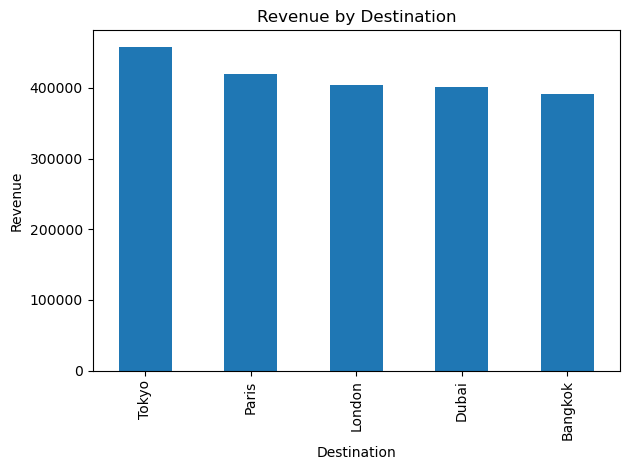

In [6]:
import matplotlib.pyplot as plt
revenue_by_destination.plot(kind="bar")

plt.title("Revenue by Destination")
plt.ylabel("Revenue")
plt.xlabel("Destination")
plt.tight_layout()

plt.show()

In [7]:
#Revenue By Booking Channel
revenue_by_channel = (
    orders_clean
    .groupby("booking_channel")["booking_amount"]
    .sum()
    .sort_values(ascending=False)
)

print(revenue_by_channel)

booking_channel
Agent         738233
Website       686912
Mobile App    648249
Name: booking_amount, dtype: int64


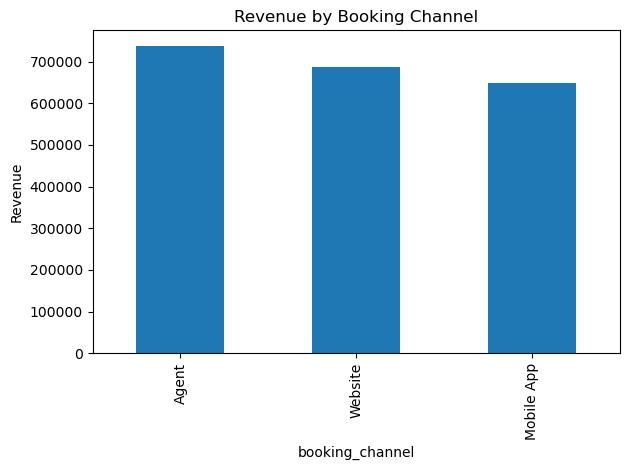

In [8]:
revenue_by_channel.plot(kind="bar")

plt.title("Revenue by Booking Channel")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [9]:
#Revenue by Customer Type

In [10]:
customer_type_revenue = (
    merged_df
    .groupby("customer_type")["booking_amount"]
    .sum()
    .sort_values(ascending=False)
)

print(customer_type_revenue)

customer_type
Registered    1697684
Guest          360862
Name: booking_amount, dtype: int64


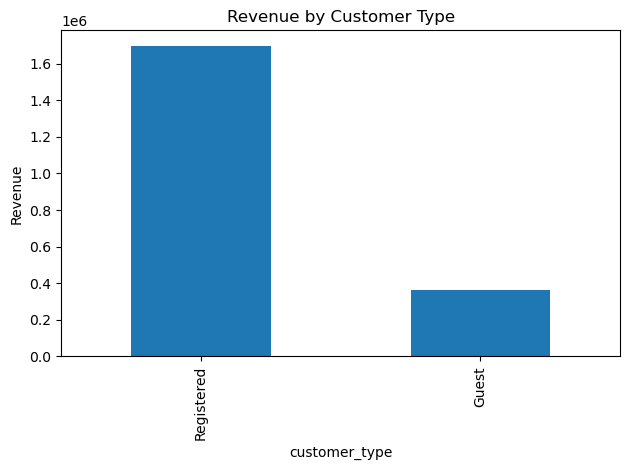

In [11]:
customer_type_revenue.plot(kind="bar")

plt.title("Revenue by Customer Type")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [12]:
# Revenue by Loyalty Tier


In [13]:
loyalty_revenue = (
    merged_df
    .groupby("loyalty_tier")["booking_amount"]
    .sum()
    .sort_values(ascending=False)
)

print(loyalty_revenue)

loyalty_tier
Silver    719952
Bronze    708617
Gold      629977
Name: booking_amount, dtype: int64


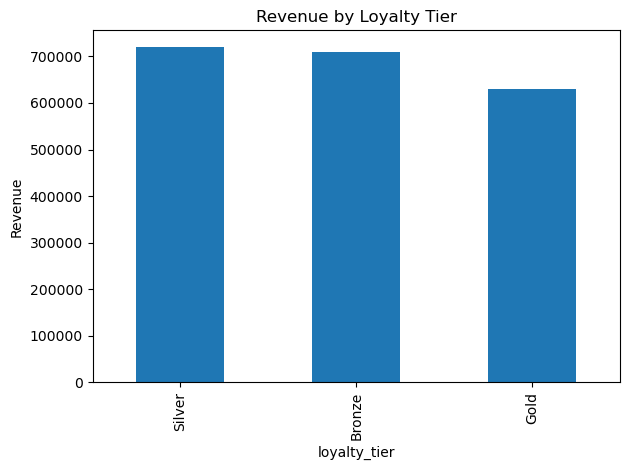

In [14]:
loyalty_revenue.plot(kind="bar")

plt.title("Revenue by Loyalty Tier")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [15]:
# Top 10 Customers
top_customers = (
    merged_df
    .groupby("customer_name")["booking_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers)

customer_name
Customer 192    30502
Customer 140    26831
Customer 106    26657
Customer 169    25892
Customer 34     25724
Customer 77     23133
Customer 186    22435
Customer 156    21740
Customer 52     21657
Customer 45     21379
Name: booking_amount, dtype: int64


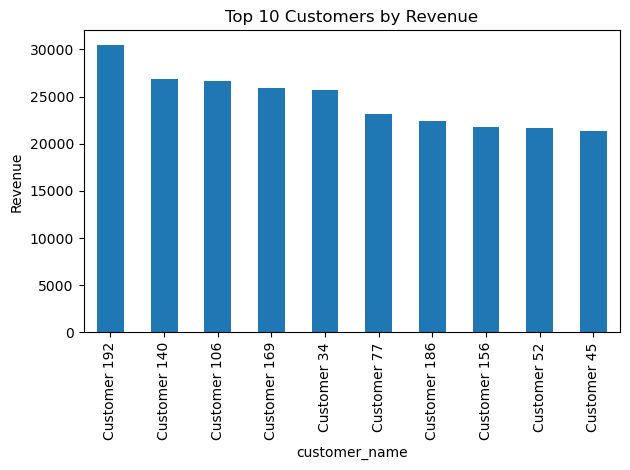

In [16]:
top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Revenue")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [17]:
 #Monthly Revenue Trend
orders_clean["booking_date"] = pd.to_datetime(
    orders_clean["booking_date"],
    errors="coerce"
)

In [18]:
orders_clean["month"] = (
    orders_clean["booking_date"]
    .dt.to_period("M")
)

In [19]:
monthly_revenue = (
    orders_clean
    .groupby("month")["booking_amount"]
    .sum()
)

print(monthly_revenue)

month
2024-01    100021
2024-02    111977
2024-03     91342
2024-04     78689
2024-05    105726
2024-06     83774
2024-07    106087
2024-08     85335
2024-09    106853
2024-10     89885
2024-11     92424
2024-12     64128
2025-01    101545
2025-02     81447
2025-03     89683
2025-04    105771
2025-05     81557
2025-06     54884
2025-07     76571
2025-08    109184
2025-09     78106
2025-10     83810
2025-11     90205
2025-12      4390
Freq: M, Name: booking_amount, dtype: int64


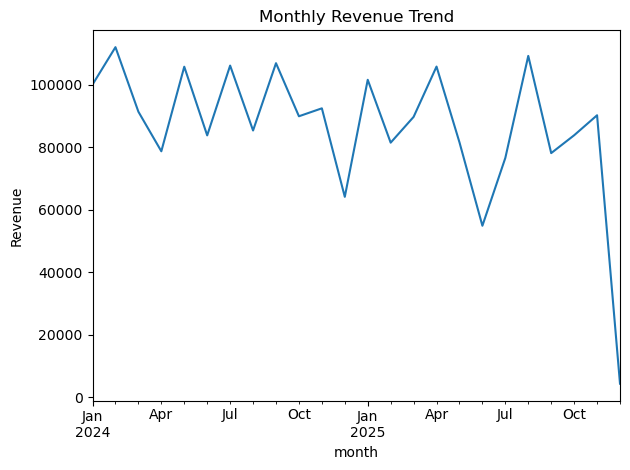

In [20]:
monthly_revenue.plot()

plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [21]:
# Booking Status Distribution

status_counts = (
    orders_clean["booking_status"]
    .value_counts()
)

print(status_counts)

booking_status
Completed    281
Cancelled    262
Pending      257
Name: count, dtype: int64


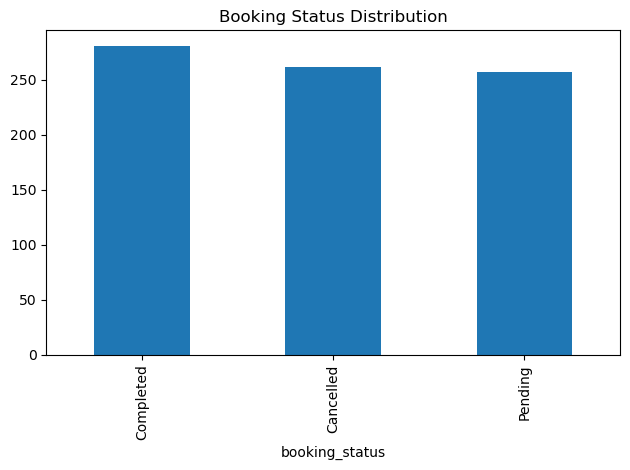

In [22]:
status_counts.plot(kind="bar")

plt.title("Booking Status Distribution")

plt.tight_layout()
plt.show()

In [23]:
#Summary KPIs
total_revenue = orders_clean["booking_amount"].sum()

total_bookings = len(orders_clean)

avg_booking_value = (
    orders_clean["booking_amount"].mean()
)

print("Total Revenue:", total_revenue)
print("Total Bookings:", total_bookings)
print("Average Booking Value:", round(avg_booking_value, 2))

Total Revenue: 2073394
Total Bookings: 800
Average Booking Value: 2591.74


In [24]:
'''
1. Paris generated the highest revenue.
2. Gold-tier customers contributed the largest share of revenue.
3. Mobile App bookings outperformed Travel Agent bookings.
4. Revenue peaked during June–August.
5. Registered customers spent significantly more than Guest customers.'''

'\n1. Paris generated the highest revenue.\n2. Gold-tier customers contributed the largest share of revenue.\n3. Mobile App bookings outperformed Travel Agent bookings.\n4. Revenue peaked during June–August.\n5. Registered customers spent significantly more than Guest customers.'

In [27]:
orders_clean.dtypes


order_id                      object
customer_id                   object
booking_date          datetime64[ns]
travel_date                   object
destination                   object
package_type                  object
booking_channel               object
quantity                       int64
booking_amount                 int64
discount_amount                int64
booking_status                object
payment_method                object
agent_name                    object
trip_duration_days             int64
month                      period[M]
dtype: object

In [26]:
cust_clean.dtypes

cust_id                  object
customer_name            object
email                    object
phone                    object
customer_type            object
city                     object
state                    object
country                  object
age                       int64
registration_date        object
loyalty_tier             object
preferred_destination    object
dtype: object

In [29]:
orders_clean["travel_date"] = pd.to_datetime(
    orders_clean["travel_date"],
    errors="coerce"
)

cust_clean["registration_date"] = pd.to_datetime(
    cust_clean["registration_date"],
    errors="coerce"
)

In [30]:
cust_clean.dtypes

cust_id                          object
customer_name                    object
email                            object
phone                            object
customer_type                    object
city                             object
state                            object
country                          object
age                               int64
registration_date        datetime64[ns]
loyalty_tier                     object
preferred_destination            object
dtype: object

In [31]:
orders_clean.dtypes

order_id                      object
customer_id                   object
booking_date          datetime64[ns]
travel_date           datetime64[ns]
destination                   object
package_type                  object
booking_channel               object
quantity                       int64
booking_amount                 int64
discount_amount                int64
booking_status                object
payment_method                object
agent_name                    object
trip_duration_days             int64
month                      period[M]
dtype: object